In [1]:
import sys
from pathlib import Path

raiz = Path.cwd()
if raiz.name == "notebooks":
    raiz = raiz.parent
sys.path.insert(0, str(raiz))

from lakehouse import Lakehouse
from analisis_comun import (FILTRO, CONTEOS, GRUPO_EDAD, GRUPO_ALTITUD, GRUPO_POBREZA, GRUPO_IDH,
                            ORDEN_EDAD, ORDEN_ALTITUD, ORDEN_POBREZA, ORDEN_IDH, con_intervalos, barras)

db = Lakehouse()
consultar = db.consultar
ejecutar = db.ejecutar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

figuras = raiz / "figuras"
figuras.mkdir(exist_ok=True)
TERMINO = "duracion_embarazo_semanas >= 37"


def mapa_calor(ax, tabla, titulo, etiqueta):
    """Tabla (filas × columnas) de % como mapa de calor con el valor en cada celda."""
    imagen = ax.imshow(tabla.to_numpy(dtype=float), cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(tabla.shape[1]), tabla.columns, rotation=30, ha='right')
    ax.set_yticks(range(tabla.shape[0]), tabla.index)
    for (i, j), valor in np.ndenumerate(tabla.to_numpy(dtype=float)):
        if not np.isnan(valor):
            ax.text(j, i, f'{valor:.1f}', ha='center', va='center', fontsize=8)
    ax.set_title(titulo)
    plt.colorbar(imagen, ax=ax, label=etiqueta)

      valor  nacimientos  bajo_peso  nacimientos_termino  bajo_peso_termino  peso_medio_termino_g  porcentaje_bajo_peso  ic95_inferior  ic95_superior  porcentaje_bajo_peso_termino
     <500 m      2916623     152572              2728791              55485                3361.0                  5.23           5.21           5.26                          2.03
 500-1499 m       401094      18527               380642               7352                3364.0                  4.62           4.55           4.68                          1.93
1500-2499 m       322208      16233               305641               6785                3307.0                  5.04           4.96           5.11                          2.22
2500-2999 m       346889      22247               327758              10411                3231.0                  6.41           6.33           6.50                          3.18
3000-3499 m       483763      30545               458803              14947                3217.0   

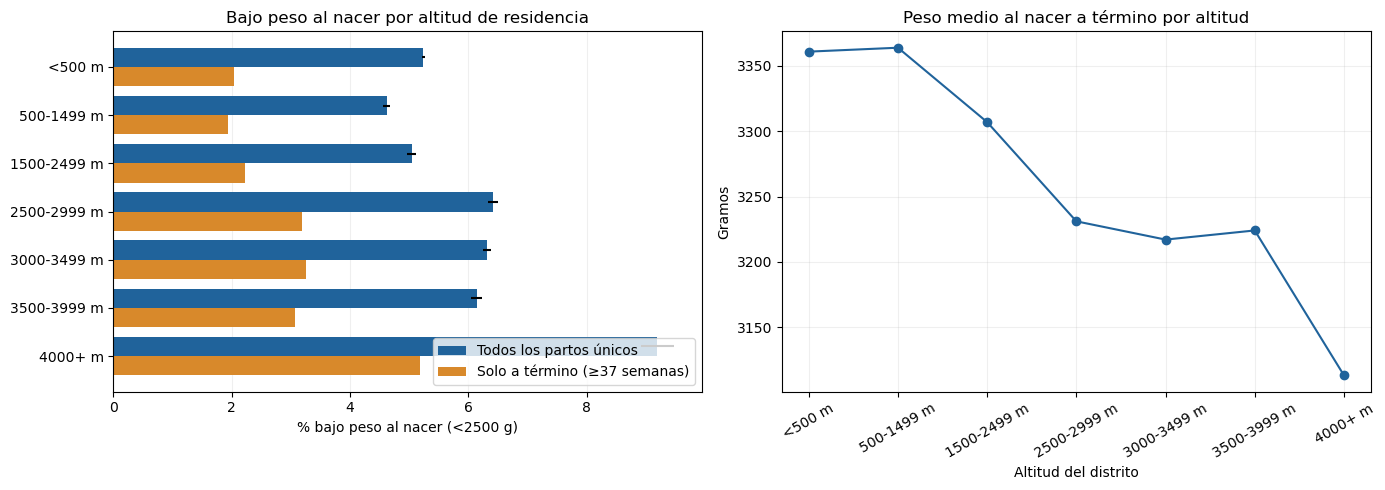

In [2]:
# 1. Altitud del distrito de residencia: bajo peso y peso medio a término
conteos_altitud = f"""SELECT {GRUPO_ALTITUD} AS valor, {CONTEOS},
       ROUND(AVG(CASE WHEN {TERMINO} THEN peso_nacido_g END), 0) AS peso_medio_termino_g
FROM __CATALOGO__.curated.nacimientos_peru
WHERE {FILTRO}
GROUP BY ALL"""
ejecutar(f"""CREATE OR REPLACE TABLE __CATALOGO__.analytics.bajo_peso_altitud
USING DELTA AS
{con_intervalos(conteos_altitud)}""")
altitud = consultar('SELECT * FROM __CATALOGO__.analytics.bajo_peso_altitud')
altitud = altitud.set_index('valor').reindex(ORDEN_ALTITUD + ['SIN DATO']).dropna(subset=['nacimientos']).reset_index()
print(altitud.to_string(index=False))
total_analisis = int(altitud['nacimientos'].sum())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
barras(ax1, altitud, 'Bajo peso al nacer por altitud de residencia', orden=ORDEN_ALTITUD)
ax1.legend(loc='lower right')
datos = altitud[altitud['valor'].isin(ORDEN_ALTITUD)]
ax2.plot(datos['valor'], datos['peso_medio_termino_g'], marker='o', color='#20639B')
ax2.set(title='Peso medio al nacer a término por altitud', xlabel='Altitud del distrito', ylabel='Gramos')
ax2.tick_params(axis='x', rotation=30)
ax2.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(figuras / 'bajo_peso_altitud.png', dpi=180)
plt.show()


 macroregion
              valor  nacimientos  bajo_peso  nacimientos_termino  bajo_peso_termino  porcentaje_bajo_peso  ic95_inferior  ic95_superior  porcentaje_bajo_peso_termino
      LIMA Y CALLAO      1575423      72336              1478624              22949                  4.59           4.56           4.62                          1.55
 MACROREGION CENTRO       835012      48923               793209              23646                  5.86           5.81           5.91                          2.98
  MACROREGION NORTE      1153566      70720              1077863              28951                  6.13           6.09           6.17                          2.69
MACROREGION ORIENTE       543784      36918               506342              16850                  6.79           6.72           6.86                          3.33
    MACROREGION SUR       688178      32396               654259              12846                  4.71           4.66           4.76                     

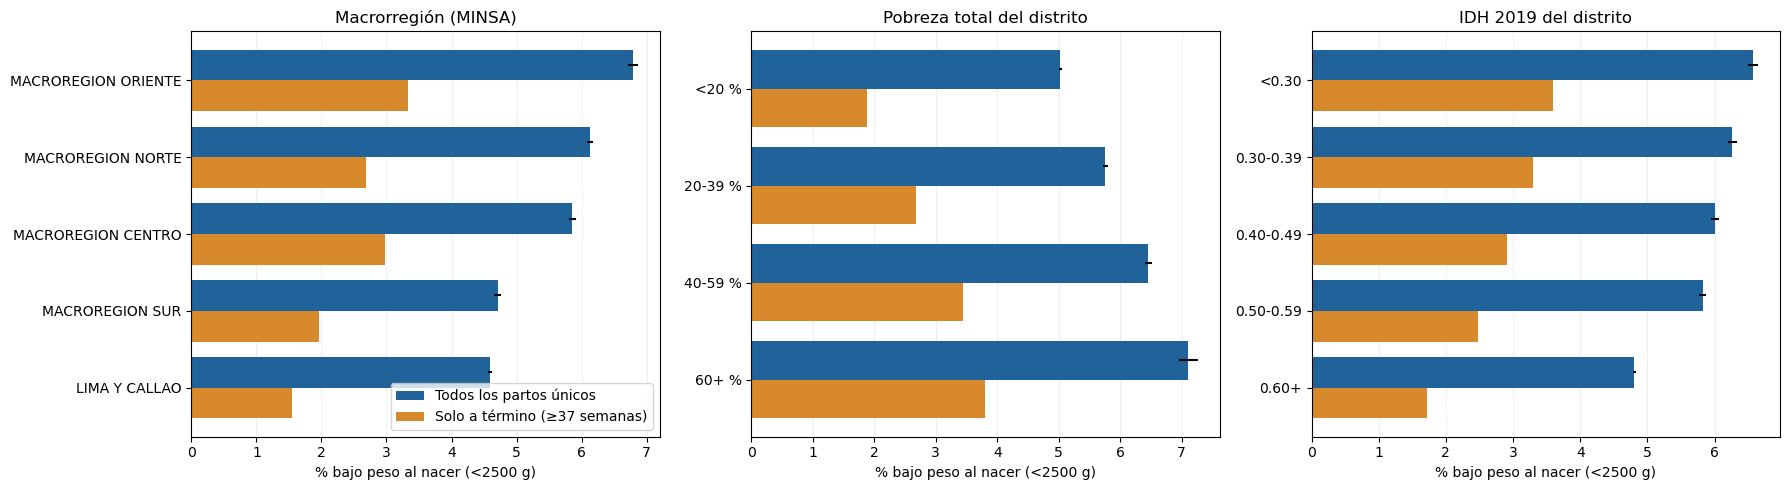

In [3]:
# 2. Macrorregión, pobreza e IDH del distrito
conteos_territorio = f"""SELECT dim.variable, dim.valor, {CONTEOS}
FROM __CATALOGO__.curated.nacimientos_peru
LATERAL VIEW EXPLODE(ARRAY(
  NAMED_STRUCT('variable', 'macroregion', 'valor', COALESCE(macroregion, 'SIN DATO')),
  NAMED_STRUCT('variable', 'pobreza', 'valor', {GRUPO_POBREZA}),
  NAMED_STRUCT('variable', 'idh', 'valor', {GRUPO_IDH})
)) e AS dim
WHERE {FILTRO}
GROUP BY dim.variable, dim.valor"""
ejecutar(f"""CREATE OR REPLACE TABLE __CATALOGO__.analytics.bajo_peso_territorio
USING DELTA AS
{con_intervalos(conteos_territorio)}""")
territorio = consultar('SELECT * FROM __CATALOGO__.analytics.bajo_peso_territorio')
for variable in ['macroregion', 'pobreza', 'idh']:
    datos = territorio[territorio['variable'] == variable]
    assert int(datos['nacimientos'].sum()) == total_analisis
    print('\n', variable)
    print(datos.drop(columns='variable').sort_values('valor').to_string(index=False))

fig, ejes = plt.subplots(1, 3, figsize=(18, 5))
sin_dato = territorio['valor'] != 'SIN DATO'
barras(ejes[0], territorio[(territorio['variable'] == 'macroregion') & sin_dato], 'Macrorregión (MINSA)')
barras(ejes[1], territorio[territorio['variable'] == 'pobreza'], 'Pobreza total del distrito', orden=ORDEN_POBREZA)
barras(ejes[2], territorio[territorio['variable'] == 'idh'], 'IDH 2019 del distrito', orden=ORDEN_IDH)
ejes[0].legend(loc='lower right')
fig.tight_layout()
fig.savefig(figuras / 'bajo_peso_territorio.png', dpi=180)
plt.show()

% bajo peso a término, edad (filas) × altitud (columnas):
grupo_altitud  <500 m  500-1499 m  1500-2499 m  2500-2999 m  3000-3499 m  3500-3999 m  4000+ m
grupo_edad                                                                                    
10-14             5.4         4.5          4.2          6.7          6.9          6.0      NaN
15-19             3.3         2.9          3.2          4.2          4.5          4.1      6.2
20-34             1.8         1.7          2.0          2.8          2.9          2.7      4.9
35-39             1.8         1.8          2.2          3.2          3.2          3.4      5.1
40-44             2.3         2.1          3.1          4.3          4.1          4.0      6.3
45-60             3.0         2.9          4.6          5.6          5.7          4.6      NaN

% bajo peso, edad (filas) × hijos vivos (columnas):
hijos_vivos     1     2     3    4  >=5
grupo_edad                             
10-14        11.5  11.4   NaN  NaN  NaN
15-19    

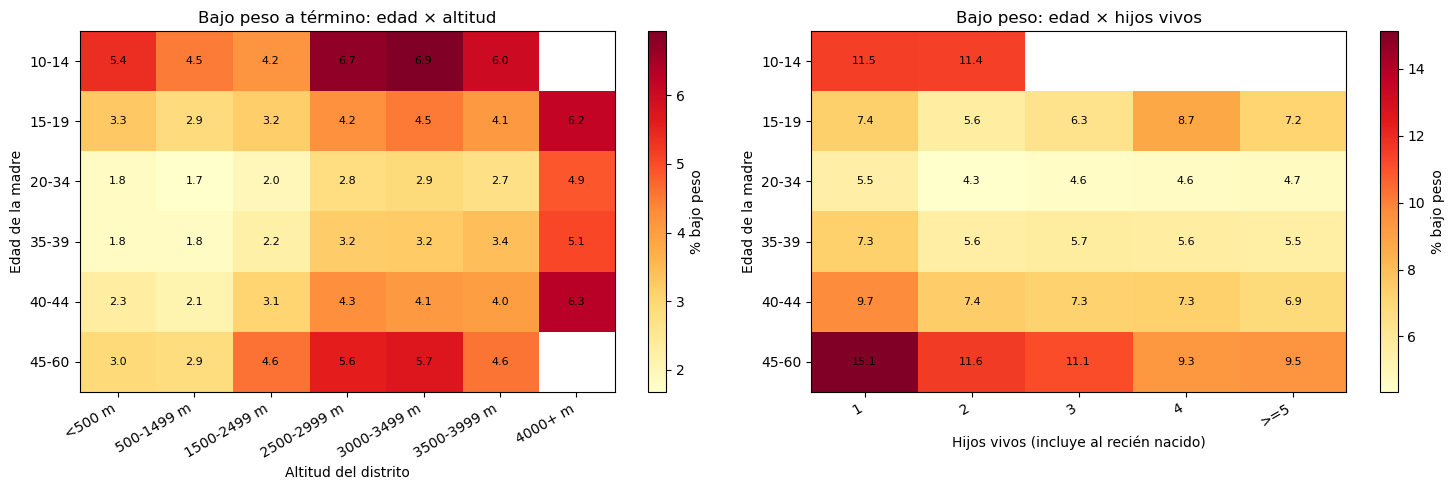

In [4]:
# 3. Interacciones: edad × altitud (a término) y edad × hijos vivos (todos)
cruces = consultar(f"""
SELECT {GRUPO_EDAD} AS grupo_edad,
       {GRUPO_ALTITUD} AS grupo_altitud,
       COALESCE(hijos_vivos_madre_cat, 'SIN DATO') AS hijos_vivos,
       COUNT(*) AS nacimientos,
       COUNT_IF(es_bajo_peso_nacer) AS bajo_peso,
       COUNT_IF({TERMINO}) AS nacimientos_termino,
       COUNT_IF(es_bajo_peso_nacer AND {TERMINO}) AS bajo_peso_termino
FROM __CATALOGO__.curated.nacimientos_peru
WHERE {FILTRO}
GROUP BY ALL
""")
assert int(cruces['nacimientos'].sum()) == total_analisis


def porcentaje(filas, columnas, casos, total, minimo=200):
    tabla = cruces.groupby([filas, columnas])[[casos, total]].sum()
    tabla = (100 * tabla[casos] / tabla[total]).where(tabla[total] >= minimo)
    return tabla.unstack()


edad_altitud = porcentaje('grupo_edad', 'grupo_altitud', 'bajo_peso_termino', 'nacimientos_termino')
edad_altitud = edad_altitud.reindex(index=ORDEN_EDAD, columns=ORDEN_ALTITUD)
edad_hijos = porcentaje('grupo_edad', 'hijos_vivos', 'bajo_peso', 'nacimientos')
edad_hijos = edad_hijos.reindex(index=ORDEN_EDAD, columns=['1', '2', '3', '4', '>=5'])
print('% bajo peso a término, edad (filas) × altitud (columnas):')
print(edad_altitud.round(1).to_string())
print('\n% bajo peso, edad (filas) × hijos vivos (columnas):')
print(edad_hijos.round(1).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
mapa_calor(ax1, edad_altitud, 'Bajo peso a término: edad × altitud', '% bajo peso')
ax1.set(xlabel='Altitud del distrito', ylabel='Edad de la madre')
mapa_calor(ax2, edad_hijos, 'Bajo peso: edad × hijos vivos', '% bajo peso')
ax2.set(xlabel='Hijos vivos (incluye al recién nacido)', ylabel='Edad de la madre')
fig.tight_layout()
fig.savefig(figuras / 'interacciones_edad.png', dpi=180)
plt.show()

139 provincias con al menos 5000 partos
                          valor  nacimientos  bajo_peso  nacimientos_termino  bajo_peso_termino  porcentaje_bajo_peso  ic95_inferior  ic95_superior  porcentaje_bajo_peso_termino
                  PASCO (PASCO)        22298       2380                20653               1278                 10.67          10.28          11.09                          6.19
         SAN MIGUEL (CAJAMARCA)         5698        598                 5254                291                 10.49           9.73          11.32                          5.54
              ATALAYA (UCAYALI)        12874       1071                12102                644                  8.32           7.85           8.81                          5.32
          HUALGAYOC (CAJAMARCA)        13446       1320                12499                661                  9.82           9.33          10.33                          5.29
         SAN MARCOS (CAJAMARCA)         8484        762               

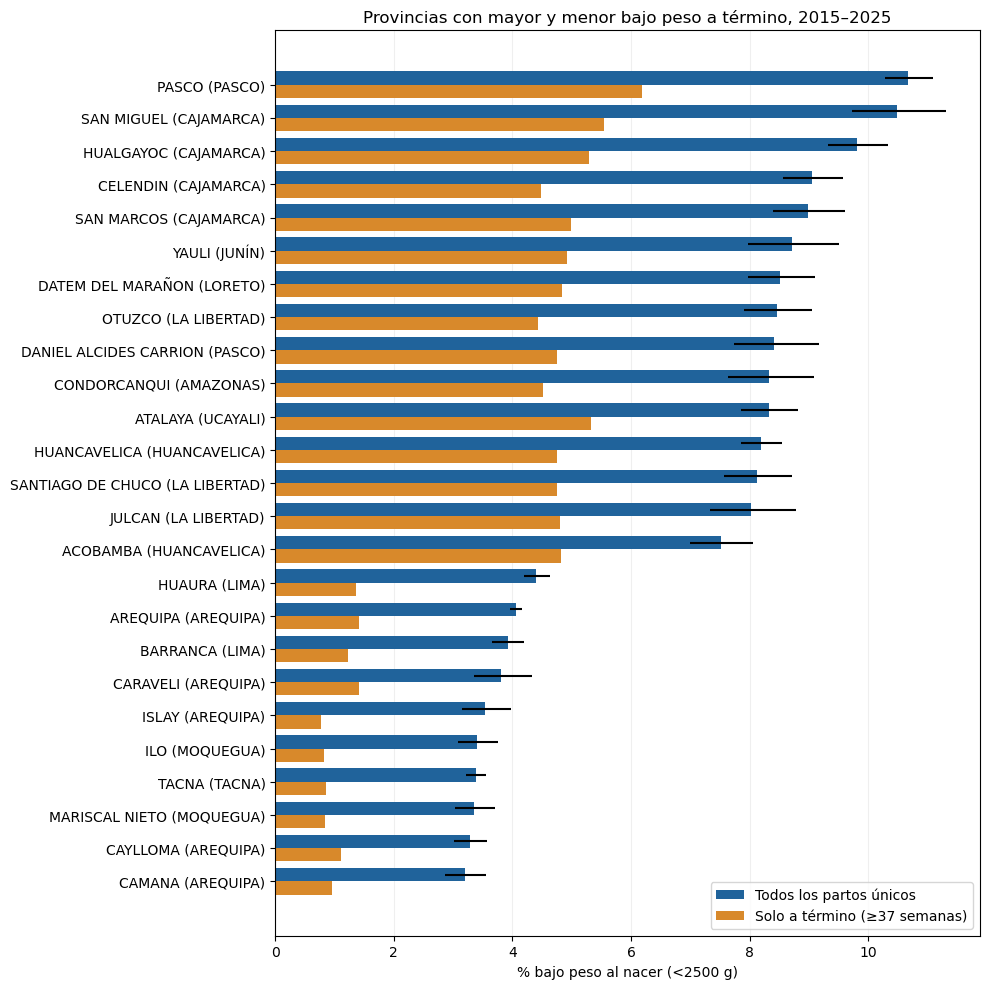

In [5]:
# 4. Provincias con mayor y menor bajo peso a término (al menos 5000 partos)
conteos_provincia = f"""SELECT CONCAT(provincia, ' (', departamento_residencia, ')') AS valor, {CONTEOS}
FROM __CATALOGO__.curated.nacimientos_peru
WHERE {FILTRO} AND provincia IS NOT NULL
GROUP BY ALL"""
ejecutar(f"""CREATE OR REPLACE TABLE __CATALOGO__.analytics.bajo_peso_provincia
USING DELTA AS
{con_intervalos(conteos_provincia)}""")
provincias = consultar(f"""
SELECT * FROM __CATALOGO__.analytics.bajo_peso_provincia
WHERE nacimientos >= 5000
ORDER BY porcentaje_bajo_peso_termino DESC
""")
extremos = pd.concat([provincias.head(15), provincias.tail(10)])
print(f'{len(provincias)} provincias con al menos 5000 partos')
print(extremos.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 10))
barras(ax, extremos, 'Provincias con mayor y menor bajo peso a término, 2015–2025')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(figuras / 'bajo_peso_provincias.png', dpi=180)
plt.show()

macroregion      LIMA Y CALLAO  MACROREGION CENTRO  MACROREGION NORTE  MACROREGION ORIENTE  MACROREGION SUR
anio_nacimiento                                                                                            
2015                      4.53                5.92               6.40                 6.79             4.73
2016                      4.42                5.67               6.21                 6.66             4.50
2017                      4.26                5.69               6.04                 6.21             4.53
2018                      4.39                5.57               5.74                 6.15             4.45
2019                      4.56                5.56               5.98                 6.36             4.62
2020                      4.34                5.39               5.86                 6.70             4.39
2021                      4.73                5.86               5.91                 6.66             4.71
2022                      4.

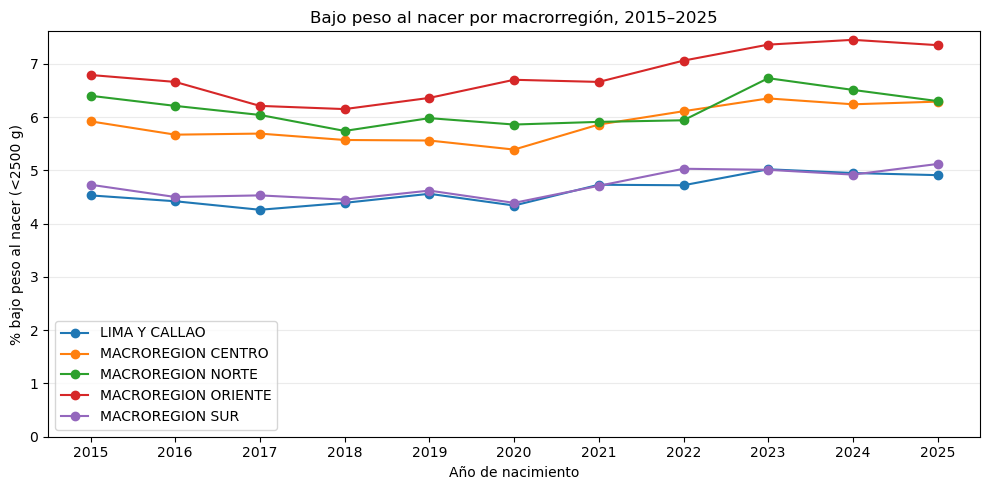

In [6]:
# 5. Tendencia anual por macrorregión
conteos_tendencia = f"""SELECT anio_nacimiento, COALESCE(macroregion, 'SIN DATO') AS macroregion, {CONTEOS}
FROM __CATALOGO__.curated.nacimientos_peru
WHERE {FILTRO}
GROUP BY ALL"""
tendencia = consultar(con_intervalos(conteos_tendencia))
tendencia = tendencia[tendencia['macroregion'] != 'SIN DATO']
tabla_tendencia = tendencia.pivot(index='anio_nacimiento', columns='macroregion', values='porcentaje_bajo_peso')
print(tabla_tendencia.round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
for macroregion, datos in tendencia.groupby('macroregion'):
    datos = datos.sort_values('anio_nacimiento')
    ax.plot(datos['anio_nacimiento'], datos['porcentaje_bajo_peso'], marker='o', label=macroregion)
ax.set(title='Bajo peso al nacer por macrorregión, 2015–2025', xlabel='Año de nacimiento',
       ylabel='% bajo peso al nacer (<2500 g)')
ax.set_xticks(sorted(tendencia['anio_nacimiento'].unique()))
ax.set_ylim(bottom=0)
ax.grid(axis='y', alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(figuras / 'tendencia_macroregion.png', dpi=180)
plt.show()

1230 establecimientos con al menos 100 partos; media nacional 5.45 %
            establecimientos  nacimientos
fuera                                    
Dentro                   614       707053
Por debajo               505      2262124
Por encima               111      1809790


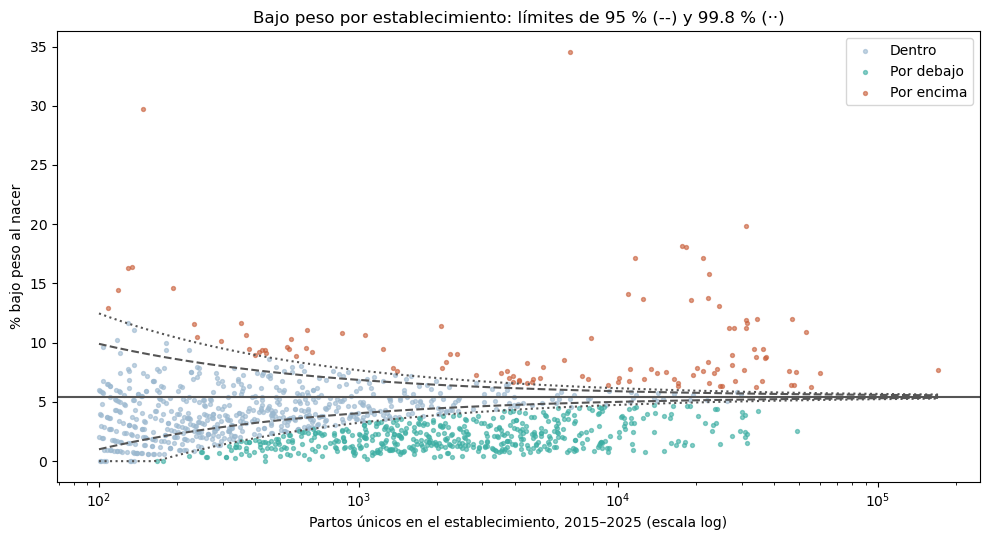

In [7]:
# 6. Variación entre establecimientos de salud (gráfico de embudo)
# Los establecimientos fuera de los límites tienen más (o menos) bajo peso del esperable por azar;
# los hospitales de referencia concentran embarazos de alto riesgo, así que no mide calidad de atención.
establecimientos = consultar(f"""
SELECT codigo_ipress,
       COUNT(*) AS nacimientos,
       COUNT_IF(es_bajo_peso_nacer) AS bajo_peso
FROM __CATALOGO__.curated.nacimientos_peru
WHERE {FILTRO} AND codigo_ipress IS NOT NULL
GROUP BY codigo_ipress
HAVING COUNT(*) >= 100
""")
p0 = establecimientos['bajo_peso'].sum() / establecimientos['nacimientos'].sum()
establecimientos['porcentaje'] = 100 * establecimientos['bajo_peso'] / establecimientos['nacimientos']
error = np.sqrt(p0 * (1 - p0) / establecimientos['nacimientos'])
establecimientos['fuera'] = np.where(establecimientos['porcentaje'] > 100 * (p0 + 3.09 * error), 'Por encima',
                             np.where(establecimientos['porcentaje'] < 100 * (p0 - 3.09 * error), 'Por debajo',
                                      'Dentro'))
resumen_ipress = establecimientos.groupby('fuera').agg(establecimientos=('codigo_ipress', 'size'),
                                                       nacimientos=('nacimientos', 'sum'))
print(f'{len(establecimientos)} establecimientos con al menos 100 partos; media nacional {100 * p0:.2f} %')
print(resumen_ipress.to_string())

n = np.logspace(2, np.log10(establecimientos['nacimientos'].max()), 200)
fig, ax = plt.subplots(figsize=(10, 5.5))
colores = {'Dentro': '#9BB8CF', 'Por encima': '#C85D38', 'Por debajo': '#3CAEA3'}
for grupo, datos in establecimientos.groupby('fuera'):
    ax.scatter(datos['nacimientos'], datos['porcentaje'], s=8, alpha=0.6, color=colores[grupo], label=grupo)
for z, estilo in [(1.96, '--'), (3.09, ':')]:
    limite = z * np.sqrt(p0 * (1 - p0) / n)
    ax.plot(n, 100 * (p0 + limite), color='#555555', linestyle=estilo)
    ax.plot(n, 100 * np.maximum(p0 - limite, 0), color='#555555', linestyle=estilo)
ax.axhline(100 * p0, color='#555555')
ax.set_xscale('log')
ax.set(title='Bajo peso por establecimiento: límites de 95 % (--) y 99.8 % (··)',
       xlabel='Partos únicos en el establecimiento, 2015–2025 (escala log)', ylabel='% bajo peso al nacer')
ax.legend()
fig.tight_layout()
fig.savefig(figuras / 'embudo_establecimientos.png', dpi=180)
plt.show()

In [8]:
# 7. Resumen de patrones territoriales
def tasa(tabla, valor, columna='porcentaje_bajo_peso_termino'):
    return float(tabla.loc[tabla['valor'] == valor, columna].iloc[0])


print(f"Bajo peso a término: {tasa(altitud, '<500 m'):.1f} % bajo 500 m frente a "
      f"{tasa(altitud, '4000+ m'):.1f} % sobre 4000 m; el peso medio a término baja "
      f"{tasa(altitud, '<500 m', 'peso_medio_termino_g') - tasa(altitud, '4000+ m', 'peso_medio_termino_g'):.0f} g.")
pobreza = territorio[territorio['variable'] == 'pobreza']
print(f"Pobreza del distrito: {tasa(pobreza, '<20 %'):.1f} % (<20 % de pobreza) frente a "
      f"{tasa(pobreza, '60+ %'):.1f} % (60 % o más) a término.")
print(f"Provincia con mayor bajo peso a término: {provincias.iloc[0]['valor']} "
      f"({provincias.iloc[0]['porcentaje_bajo_peso_termino']:.1f} %); menor: {provincias.iloc[-1]['valor']} "
      f"({provincias.iloc[-1]['porcentaje_bajo_peso_termino']:.1f} %).")
print(f"Establecimientos por encima del límite de 99.8 %: {(establecimientos['fuera'] == 'Por encima').sum()} "
      f"de {len(establecimientos)}.")
print('Patrones descriptivos y ecológicos (contexto del distrito): no prueban causalidad.')

Bajo peso a término: 2.0 % bajo 500 m frente a 5.2 % sobre 4000 m; el peso medio a término baja 248 g.
Pobreza del distrito: 1.9 % (<20 % de pobreza) frente a 3.8 % (60 % o más) a término.
Provincia con mayor bajo peso a término: PASCO (PASCO) (6.2 %); menor: ISLAY (AREQUIPA) (0.8 %).
Establecimientos por encima del límite de 99.8 %: 111 de 1230.
Patrones descriptivos y ecológicos (contexto del distrito): no prueban causalidad.
